# SaaS Product Analytics & Churn Prediction

## 01 — Data Understanding

### Objective

This notebook performs the initial understanding and quality assessment of the SaaS analytics datasets.

The project uses four core datasets:

- `users.csv`
- `events.csv`
- `subscriptions.csv`
- `support_tickets.csv`

The purpose of this analysis is to understand:

- Dataset structure
- Data types
- Record counts
- Missing values
- Duplicate records
- Unique entities
- Date coverage
- Categorical distributions
- Relationships between datasets
- Initial data-quality observations

### Business Context

The goal of the overall project is to understand SaaS product usage, customer behavior, revenue performance, retention, and churn.

The analysis will eventually support:

1. Product analytics
2. Funnel analysis
3. Cohort and retention analysis
4. Revenue analytics
5. Churn analysis
6. Churn prediction
7. Model explainability
8. Customer retention prioritization

## 1. Import Libraries

The following libraries are used for:

- Data manipulation
- Numerical analysis
- Visualization
- File and path management

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Configuration

The notebook is designed to run from the project repository.

The project root is detected automatically so that the notebook does not depend on a hard-coded Windows path.

In [2]:
PROJECT_ROOT = Path.cwd()

# If the notebook is opened from the Notebooks directory,
# move one level up to the project root.
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"

print("Project root:")
print(PROJECT_ROOT)

print("\nRaw data directory:")
print(RAW_DATA_DIR)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction

Raw data directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\data\raw


## 3. Verify Dataset Files

Before loading the datasets, verify that all expected raw CSV files are available.

In [3]:
expected_files = [
    "users.csv",
    "events.csv",
    "subscriptions.csv",
    "support_tickets.csv",
]

print("Expected datasets:\n")

for filename in expected_files:
    path = RAW_DATA_DIR / filename

    status = "FOUND" if path.exists() else "MISSING"

    print(f"{filename:<25} {status}")

Expected datasets:

users.csv                 FOUND
events.csv                FOUND
subscriptions.csv         FOUND
support_tickets.csv       FOUND


## 4. Load Raw Datasets

In [4]:
users = pd.read_csv(
    RAW_DATA_DIR / "users.csv"
)

events = pd.read_csv(
    RAW_DATA_DIR / "events.csv"
)

subscriptions = pd.read_csv(
    RAW_DATA_DIR / "subscriptions.csv"
)

support_tickets = pd.read_csv(
    RAW_DATA_DIR / "support_tickets.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
datasets = {
    "Users": users,
    "Events": events,
    "Subscriptions": subscriptions,
    "Support Tickets": support_tickets,
}

dataset_summary = pd.DataFrame(
    {
        "dataset": list(datasets.keys()),
        "rows": [df.shape[0] for df in datasets.values()],
        "columns": [df.shape[1] for df in datasets.values()],
    }
)

dataset_summary

,dataset,rows,columns
0,Users,30000,12
1,Events,1552178,9
2,Subscriptions,30000,15
3,Support Tickets,9976,14


## 5. Dataset Overview

The four datasets represent different parts of the SaaS business:

| Dataset | Purpose |
|---|---|
| Users | Customer and company information |
| Events | Product usage and behavioral activity |
| Subscriptions | Subscription and revenue information |
| Support Tickets | Customer support interactions |

The datasets can be connected primarily through `user_id`.

# Users Analysis

## 6. Users Dataset

The users dataset represents the customer/account population of the SaaS platform.

We will examine:

- Dataset dimensions
- Columns
- Data types
- Missing values
- Duplicate users
- Unique companies
- Account status
- Acquisition sources
- Plans

In [6]:
print("Users shape:")
print(users.shape)

print("\nUsers columns:")
print(users.columns.tolist())

print("\nUsers data types:")
display(users.dtypes.to_frame("dtype"))

Users shape:
(30000, 12)

Users columns:
['user_id', 'company_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'plan', 'role', 'primary_device', 'engagement_propensity', 'onboarding_completed']

Users data types:


,dtype
user_id,str
company_id,str
signup_date,str
country,str
industry,str
company_size,str
acquisition_channel,str
plan,str
role,str
primary_device,str


In [7]:
print("Users sample:")
display(users.head())

Users sample:


,user_id,company_id,signup_date,country,industry,company_size,acquisition_channel,plan,role,primary_device,engagement_propensity,onboarding_completed
0,U011214,C05116,2024-01-01,Brazil,Technology,Large,Referral,Free,Member,Mobile,0.68,True
1,U010388,C07179,2024-01-01,United Kingdom,Manufacturing,Large,Partner,Starter,Member,Desktop,0.81,True
2,U012220,C01742,2024-01-01,Brazil,Technology,Small,Direct,Free,Member,Mobile,0.63,True
3,U029242,C03627,2024-01-01,United States,Healthcare,Large,Paid Search,Professional,Manager,Mobile,0.86,True
4,U002343,C00295,2024-01-01,United Kingdom,Education,Large,Paid Search,Free,Member,Desktop,0.63,True


In [8]:
users_missing = pd.DataFrame(
    {
        "column": users.columns,
        "missing_count": users.isna().sum().values,
        "missing_pct": (
            users.isna().mean().values * 100
        ),
    }
).sort_values(
    "missing_count",
    ascending=False,
)

display(users_missing)

,column,missing_count,missing_pct
0,user_id,0,0.00
1,company_id,0,0.00
2,signup_date,0,0.00
3,country,0,0.00
4,industry,0,0.00
5,company_size,0,0.00
6,acquisition_channel,0,0.00
7,plan,0,0.00
8,role,0,0.00
9,primary_device,0,0.00


In [9]:
print(
    "Duplicate user_id records:",
    users["user_id"].duplicated().sum()
)

print(
    "Unique users:",
    users["user_id"].nunique()
)

if "company_id" in users.columns:
    print(
        "Unique companies:",
        users["company_id"].nunique()
    )

Duplicate user_id records: 0
Unique users: 30000
Unique companies: 7744


In [10]:
if "plan" in users.columns:
    print("Users by plan:")
    display(
        users["plan"]
        .value_counts(dropna=False)
        .to_frame("users")
    )

if "status" in users.columns:
    print("Users by status:")
    display(
        users["status"]
        .value_counts(dropna=False)
        .to_frame("users")
    )

if "acquisition_source" in users.columns:
    print("Users by acquisition source:")
    display(
        users["acquisition_source"]
        .value_counts(dropna=False)
        .to_frame("users")
    )

Users by plan:


,users
plan,
Free,11993
Starter,8316
Professional,7271
Enterprise,2420


# Events Analysis

## 7. Events Dataset

The events dataset contains product usage activity.

This dataset is particularly important because it allows us to measure:

- Daily active users
- Weekly active users
- Monthly active users
- Feature usage
- Engagement frequency
- User journeys
- Funnel progression
- Behavioral churn indicators

In [11]:
print("Events shape:")
print(events.shape)

print("\nEvents columns:")
print(events.columns.tolist())

print("\nEvents data types:")
display(events.dtypes.to_frame("dtype"))

Events shape:
(1552178, 9)

Events columns:
['event_id', 'user_id', 'company_id', 'event_timestamp', 'event_type', 'feature', 'session_id', 'device', 'session_duration_minutes']

Events data types:


,dtype
event_id,str
user_id,str
company_id,str
event_timestamp,str
event_type,str
feature,str
session_id,str
device,str
session_duration_minutes,float64


In [12]:
print("Events sample:")
display(events.head())

Events sample:


,event_id,user_id,company_id,event_timestamp,event_type,feature,session_id,device,session_duration_minutes
0,E00005929,U001250,C05076,2024-01-05 13:54:32,subscription_started,Billing,S00005646,Desktop,7.22
1,E00000867,U001408,C06792,2024-01-06 13:46:10,login,Authentication,S00000835,Desktop,4.58
2,E00002867,U001387,C04886,2024-01-07 16:04:43,project_created,Project Management,S00002739,Mobile,13.09
3,E00007718,U022162,C01687,2024-01-07 18:56:54,task_completed,Task Management,S00007354,Desktop,9.93
4,E00001173,U025402,C07723,2024-01-08 00:02:10,comment_added,Collaboration,S00001107,Desktop,2.77


In [13]:
events_missing = pd.DataFrame(
    {
        "column": events.columns,
        "missing_count": events.isna().sum().values,
        "missing_pct": (
            events.isna().mean().values * 100
        ),
    }
).sort_values(
    "missing_count",
    ascending=False,
)

display(events_missing)

,column,missing_count,missing_pct
0,event_id,0,0.00
1,user_id,0,0.00
2,company_id,0,0.00
3,event_timestamp,0,0.00
4,event_type,0,0.00
5,feature,0,0.00
6,session_id,0,0.00
7,device,0,0.00
8,session_duration_minutes,0,0.00


In [14]:
print(
    "Duplicate event records:",
    events.duplicated().sum()
)

if "event_id" in events.columns:
    print(
        "Duplicate event IDs:",
        events["event_id"].duplicated().sum()
    )

if "user_id" in events.columns:
    print(
        "Unique users with events:",
        events["user_id"].nunique()
    )

Duplicate event records: 0
Duplicate event IDs: 0
Unique users with events: 30000


In [15]:
if "event_type" in events.columns:
    print("Event type distribution:")
    
    event_distribution = (
        events["event_type"]
        .value_counts()
        .to_frame("event_count")
    )

    display(event_distribution)

Event type distribution:


,event_count
event_type,
login,384451
task_completed,299544
task_created,296439
project_created,162088
comment_added,113206
file_uploaded,85911
team_member_invited,55495
subscription_started,41401
report_generated,36023


In [16]:
date_candidates = [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]

event_date_column = next(
    (
        column
        for column in date_candidates
        if column in events.columns
    ),
    None,
)

print(
    "Detected event date column:",
    event_date_column,
)

if event_date_column:
    events[event_date_column] = pd.to_datetime(
        events[event_date_column],
        errors="coerce",
    )

    print(
        "Event date range:",
        events[event_date_column].min(),
        "to",
        events[event_date_column].max(),
    )

Detected event date column: event_timestamp
Event date range: 2024-01-05 13:54:32 to 2026-07-31 23:59:53


# Subscriptions Analysis

## 8. Subscriptions Dataset

The subscriptions dataset contains the commercial relationship between customers and the SaaS platform.

It supports:

- MRR analysis
- ARR analysis
- ARPU
- Subscription growth
- Plan performance
- Billing-cycle analysis
- Upgrade/downgrade analysis
- Cancellation analysis

In [17]:
print("Subscriptions shape:")
print(subscriptions.shape)

print("\nSubscription columns:")
print(subscriptions.columns.tolist())

print("\nSubscription data types:")
display(
    subscriptions.dtypes.to_frame("dtype")
)

Subscriptions shape:
(30000, 15)

Subscription columns:
['subscription_id', 'user_id', 'company_id', 'plan', 'subscription_start_date', 'subscription_end_date', 'billing_frequency', 'monthly_recurring_revenue', 'annual_contract_value', 'trial', 'status', 'acquisition_source', 'upgrade_count', 'downgrade_count', 'tenure_days']

Subscription data types:


,dtype
subscription_id,str
user_id,str
company_id,str
plan,str
subscription_start_date,str
subscription_end_date,str
billing_frequency,str
monthly_recurring_revenue,float64
annual_contract_value,float64
trial,bool


In [18]:
print("Subscription sample:")
display(
    subscriptions.head()
)

Subscription sample:


,subscription_id,user_id,company_id,plan,subscription_start_date,subscription_end_date,billing_frequency,monthly_recurring_revenue,annual_contract_value,trial,status,acquisition_source,upgrade_count,downgrade_count,tenure_days
0,SUB0000056,U017525,C02244,Starter,2024-01-02,NaN,Monthly,29.00,348.00,True,Active,Partner,0,0,941
1,SUB0000010,U017339,C04434,Free,2024-01-02,NaN,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941
2,SUB0000007,U005513,C05004,Free,2024-01-02,NaN,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941
3,SUB0000001,U011214,C05116,Free,2024-01-02,NaN,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941
4,SUB0000018,U001408,C06792,Free,2024-01-02,NaN,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941


In [19]:
subscriptions_missing = pd.DataFrame(
    {
        "column": subscriptions.columns,
        "missing_count": subscriptions.isna().sum().values,
        "missing_pct": (
            subscriptions.isna().mean().values * 100
        ),
    }
).sort_values(
    "missing_count",
    ascending=False,
)

display(
    subscriptions_missing
)

,column,missing_count,missing_pct
5,subscription_end_date,27152,90.51
6,billing_frequency,11993,39.98
0,subscription_id,0,0.00
2,company_id,0,0.00
1,user_id,0,0.00
4,subscription_start_date,0,0.00
3,plan,0,0.00
7,monthly_recurring_revenue,0,0.00
8,annual_contract_value,0,0.00
9,trial,0,0.00


In [20]:
print(
    "Duplicate subscription records:",
    subscriptions.duplicated().sum()
)

if "subscription_id" in subscriptions.columns:
    print(
        "Duplicate subscription IDs:",
        subscriptions[
            "subscription_id"
        ].duplicated().sum()
    )

if "user_id" in subscriptions.columns:
    print(
        "Unique subscribed users:",
        subscriptions[
            "user_id"
        ].nunique()
    )

Duplicate subscription records: 0
Duplicate subscription IDs: 0
Unique subscribed users: 30000


In [21]:
categorical_columns = [
    "plan",
    "billing_frequency",
    "status",
    "trial",
    "acquisition_source",
]

for column in categorical_columns:

    if column in subscriptions.columns:

        print(f"\n{column} distribution:")

        display(
            subscriptions[column]
            .value_counts(
                dropna=False
            )
            .to_frame("count")
        )


plan distribution:


,count
plan,
Free,11993
Starter,8316
Professional,7271
Enterprise,2420



billing_frequency distribution:


,count
billing_frequency,
Monthly,14076
NaN,11993
Annual,3931



status distribution:


,count
status,
Active,15159
Free,11993
Churned,2848



trial distribution:


,count
trial,
True,23065
False,6935



acquisition_source distribution:


,count
acquisition_source,
Self-Serve,23245
Sales-Assisted,4893
Partner,1862


In [22]:
date_columns = [
    "subscription_start_date",
    "subscription_end_date",
    "start_date",
    "end_date",
]

for column in date_columns:

    if column in subscriptions.columns:

        subscriptions[column] = pd.to_datetime(
            subscriptions[column],
            errors="coerce",
        )

        print(
            f"{column}: "
            f"{subscriptions[column].min()} "
            f"to "
            f"{subscriptions[column].max()}"
        )

subscription_start_date: 2024-01-02 00:00:00 to 2026-07-14 00:00:00
subscription_end_date: 2024-03-15 00:00:00 to 2026-07-31 00:00:00


# Support Tickets Analysis

## 9. Support Tickets Dataset

Support tickets provide an additional view of customer experience.

Support activity can later be used to investigate relationships between:

- Support volume
- Ticket severity
- Resolution time
- Customer engagement
- Subscription status
- Churn

This is particularly useful for understanding whether customer support friction is associated with churn.

In [23]:
print("Support tickets shape:")
print(support_tickets.shape)

print("\nSupport ticket columns:")
print(
    support_tickets.columns.tolist()
)

print("\nData types:")
display(
    support_tickets.dtypes.to_frame(
        "dtype"
    )
)

Support tickets shape:
(9976, 14)

Support ticket columns:
['ticket_id', 'user_id', 'company_id', 'created_at', 'category', 'priority', 'channel', 'status', 'resolved_at', 'resolution_time_hours', 'reopened', 'satisfaction_score', 'plan_at_ticket', 'subscription_status_at_ticket']

Data types:


,dtype
ticket_id,str
user_id,str
company_id,str
created_at,str
category,str
priority,str
channel,str
status,str
resolved_at,str
resolution_time_hours,float64


In [24]:
print("Support ticket sample:")
display(
    support_tickets.head()
)

Support ticket sample:


,ticket_id,user_id,company_id,created_at,category,priority,channel,status,resolved_at,resolution_time_hours,reopened,satisfaction_score,plan_at_ticket,subscription_status_at_ticket
0,T0000182,U013153,C07915,2024-01-31,Feature Request,Medium,Email,Open,NaN,NaN,False,3,Free,Free
1,T0000442,U022825,C00826,2024-02-18,Integration,Low,In-App Chat,Resolved,2024-02-21 20:35:37.417572502,92.59,False,3,Professional,Active
2,T0000311,U005937,C03798,2024-02-27,Account Access,Medium,Web Form,Resolved,2024-02-28 06:20:53.472769497,30.35,False,5,Free,Free
3,T0000364,U004248,C00979,2024-02-29,Technical Issue,Medium,In-App Chat,Resolved,2024-03-02 17:05:42.744318057,65.10,False,4,Professional,Active
4,T0000328,U022815,C05661,2024-02-29,Technical Issue,Low,Phone,Resolved,2024-03-10 00:00:00.000000000,240.00,False,3,Free,Free


In [26]:
tickets_missing = pd.DataFrame(
    {
        "column": support_tickets.columns,
        "missing_count": support_tickets.isna().sum().values,
        "missing_pct": (
            support_tickets.isna().mean().values
            * 100
        ),
    }
).sort_values(
    "missing_count",
    ascending=False,
)

display(
    tickets_missing
)

,column,missing_count,missing_pct
8,resolved_at,578,5.79
9,resolution_time_hours,578,5.79
2,company_id,0,0.00
3,created_at,0,0.00
0,ticket_id,0,0.00
1,user_id,0,0.00
5,priority,0,0.00
4,category,0,0.00
7,status,0,0.00
6,channel,0,0.00


In [27]:
print(
    "Duplicate support ticket records:",
    support_tickets.duplicated().sum()
)

if "ticket_id" in support_tickets.columns:
    print(
        "Duplicate ticket IDs:",
        support_tickets[
            "ticket_id"
        ].duplicated().sum()
    )

if "user_id" in support_tickets.columns:
    print(
        "Unique users with support tickets:",
        support_tickets[
            "user_id"
        ].nunique()
    )

Duplicate support ticket records: 0
Duplicate ticket IDs: 0
Unique users with support tickets: 3530


In [28]:
ticket_categorical_columns = [
    "priority",
    "status",
    "category",
    "ticket_type",
]

for column in ticket_categorical_columns:

    if column in support_tickets.columns:

        print(
            f"\n{column} distribution:"
        )

        display(
            support_tickets[
                column
            ]
            .value_counts(
                dropna=False
            )
            .to_frame("count")
        )


priority distribution:


,count
priority,
Medium,4833
Low,2935
High,1787
Urgent,421



status distribution:


,count
status,
Resolved,9398
Open,578



category distribution:


,count
category,
Technical Issue,2369
Feature Request,1420
Performance,1248
Billing,1188
Account Access,1114
Integration,961
How To,889
Data/Reporting,787


# Cross-Dataset Validation

## 10. Cross-Dataset Relationship Validation

The most important relationship across the SaaS datasets is `user_id`.

We will verify:

- Users represented in events
- Users represented in subscriptions
- Users represented in support tickets
- Whether any records reference unknown users

This is important before performing joins and feature engineering.

In [29]:
user_ids = set(
    users["user_id"].dropna()
)

event_user_ids = set(
    events["user_id"].dropna()
) if "user_id" in events.columns else set()

subscription_user_ids = set(
    subscriptions["user_id"].dropna()
) if "user_id" in subscriptions.columns else set()

ticket_user_ids = set(
    support_tickets["user_id"].dropna()
) if "user_id" in support_tickets.columns else set()

print(
    "Users referenced by events but missing from users:",
    len(event_user_ids - user_ids)
)

print(
    "Users referenced by subscriptions but missing from users:",
    len(subscription_user_ids - user_ids)
)

print(
    "Users referenced by support tickets but missing from users:",
    len(ticket_user_ids - user_ids)
)

Users referenced by events but missing from users: 0
Users referenced by subscriptions but missing from users: 0
Users referenced by support tickets but missing from users: 0


In [30]:
relationship_summary = pd.DataFrame(
    {
        "dataset": [
            "Users",
            "Events",
            "Subscriptions",
            "Support Tickets",
        ],
        "unique_users": [
            users["user_id"].nunique(),
            events["user_id"].nunique(),
            subscriptions["user_id"].nunique(),
            support_tickets["user_id"].nunique(),
        ],
    }
)

display(
    relationship_summary
)

,dataset,unique_users
0,Users,30000
1,Events,30000
2,Subscriptions,30000
3,Support Tickets,3530


# Date Coverage

## 11. Overall Date Coverage

Understanding the date range is essential because later analyses will use:

- Monthly active users
- Retention cohorts
- Revenue trends
- Churn trends
- Product adoption
- Time-based behavioral analysis

In [31]:
date_coverage = []

if event_date_column:

    date_coverage.append(
        {
            "dataset": "Events",
            "start_date": events[
                event_date_column
            ].min(),
            "end_date": events[
                event_date_column
            ].max(),
        }
    )

if "subscription_start_date" in subscriptions.columns:

    date_coverage.append(
        {
            "dataset": "Subscriptions Start",
            "start_date": subscriptions[
                "subscription_start_date"
            ].min(),
            "end_date": subscriptions[
                "subscription_start_date"
            ].max(),
        }
    )

if "subscription_end_date" in subscriptions.columns:

    date_coverage.append(
        {
            "dataset": "Subscriptions End",
            "start_date": subscriptions[
                "subscription_end_date"
            ].min(),
            "end_date": subscriptions[
                "subscription_end_date"
            ].max(),
        }
    )

display(
    pd.DataFrame(date_coverage)
)

,dataset,start_date,end_date
0,Events,2024-01-05 13:54:32,2026-07-31 23:59:53
1,Subscriptions Start,2024-01-02 00:00:00,2026-07-14 00:00:00
2,Subscriptions End,2024-03-15 00:00:00,2026-07-31 00:00:00


# Basic Visual Analysis

## 12. Initial Visual Analysis

The following charts provide a first visual understanding of the SaaS customer and product-usage data.

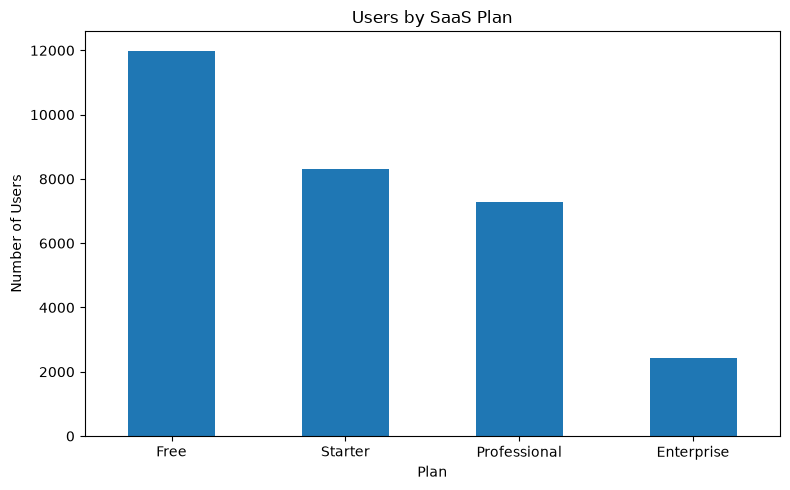

In [32]:
if "plan" in users.columns:

    plan_counts = (
        users["plan"]
        .value_counts()
    )

    plt.figure(
        figsize=(8, 5)
    )

    plan_counts.plot(
        kind="bar"
    )

    plt.title(
        "Users by SaaS Plan"
    )

    plt.xlabel(
        "Plan"
    )

    plt.ylabel(
        "Number of Users"
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    plt.show()

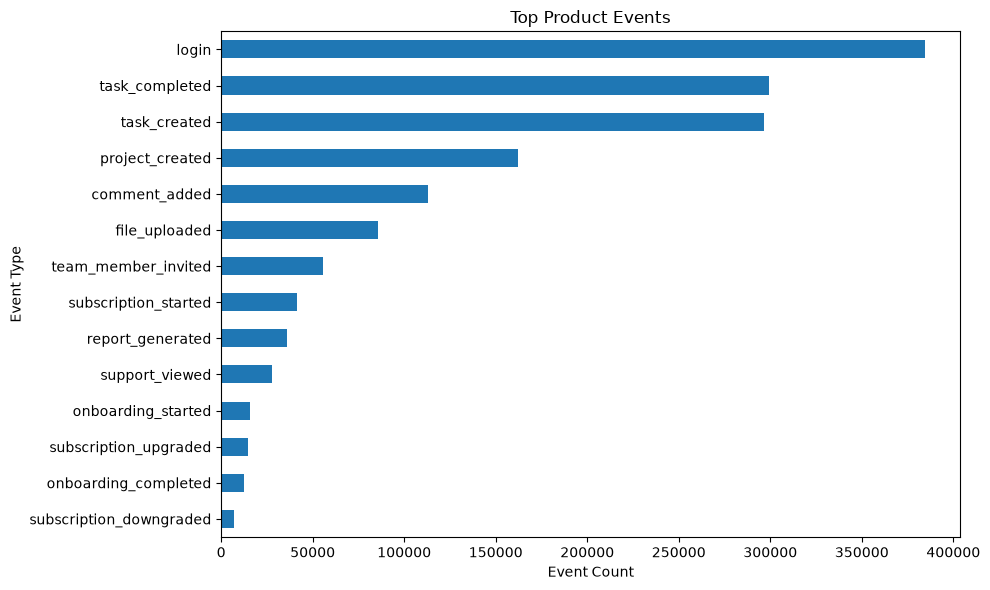

In [33]:
if "event_type" in events.columns:

    event_counts = (
        events["event_type"]
        .value_counts()
        .head(15)
    )

    plt.figure(
        figsize=(10, 6)
    )

    event_counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "Top Product Events"
    )

    plt.xlabel(
        "Event Count"
    )

    plt.ylabel(
        "Event Type"
    )

    plt.tight_layout()

    plt.show()

# Data Quality Summary

## 13. Data Quality Assessment

The following checks summarize the major data-quality dimensions:

- Row counts
- Column counts
- Missing values
- Duplicate records
- Duplicate primary keys
- Unknown foreign keys
- Date validity

In [34]:
quality_rows = []

for name, df in datasets.items():

    quality_rows.append(
        {
            "dataset": name,
            "rows": len(df),
            "columns": len(df.columns),
            "duplicate_rows": df.duplicated().sum(),
            "missing_cells": df.isna().sum().sum(),
            "missing_pct": (
                df.isna().sum().sum()
                / df.size
                * 100
            ),
        }
    )

quality_summary = pd.DataFrame(
    quality_rows
)

display(
    quality_summary
)

,dataset,rows,columns,duplicate_rows,missing_cells,missing_pct
0,Users,30000,12,0,0,0.00
1,Events,1552178,9,0,0,0.00
2,Subscriptions,30000,15,0,39145,8.70
3,Support Tickets,9976,14,0,1156,0.83


# Initial Observations

## 14. Initial Business Observations

### Customer Base

The users dataset establishes the size and composition of the SaaS customer base, including plan distribution and acquisition sources.

### Product Usage

The events dataset provides the behavioral foundation for measuring product engagement and identifying the features and actions most frequently used by customers.

### Subscription & Revenue

The subscriptions dataset provides the foundation for MRR, ARR, ARPU, subscription growth, upgrades, downgrades, and cancellations.

### Customer Support

The support ticket dataset provides a customer-experience dimension that can later be connected with engagement and churn behavior.

### Cross-Dataset Relationships

`user_id` is the primary analytical key connecting customer-level information with product usage, subscriptions, and support interactions.

### Next Analytical Steps

The next notebooks will transform this raw understanding into business analysis:

1. Product Analytics
2. Funnel Analysis
3. Retention & Cohort Analysis
4. Revenue Analytics
5. Churn Analysis
6. Churn Prediction
7. Model Explainability

## 15. Conclusion

The initial data-understanding phase establishes the structure and quality of the SaaS analytics data.

The four datasets provide complementary perspectives:

- **Users** → customer/account characteristics
- **Events** → product behavior and engagement
- **Subscriptions** → commercial and revenue behavior
- **Support Tickets** → customer support experience

These datasets provide the foundation for the subsequent SaaS analytics and churn prediction pipeline.

---

**Next Notebook:** `02_Product_Analytics.ipynb`